# AA_Cam_pose_sweeps

Sweeps camera density (target frame count, `cam_poses`) at a fixed video range (`start_3D_recon`..`end_3D_recon`) through every reconstruction technique, scores each against GPS ground truth, and pools everything into one CSV.

Process code (scoring, resumability/status tracking, disk-retention cleanup, the sweep loop itself) lives in `AA_cam_pose_sweeps.py`, next to this notebook -- import it, don't copy it, so fixes/improvements there apply to every per-case copy of this notebook automatically. This notebook only holds what varies per case:
- **Config**: `case_name`, frame range, `CAM_POSES`, `TECHNIQUE_ORDER`, `FLAGS`, and `DATA_STORAGE` (what to keep on disk afterwards vs delete).
- **Part 2 (Sweep)** is expensive (minutes per technique per density) and resumable -- safe to interrupt/kill and re-run from the top. GPU OOM kills the whole kernel outright (not a catchable Python exception), so the resumability design is disk-based, not in-process -- see `AA_cam_pose_sweeps.py`'s Resumability infrastructure section.
- **Part 3 (Load + plot)** is cheap -- it only reads the pooled CSV off disk, so the chart can be restyled/re-run any number of times without re-touching the sweep. Stays notebook-side since it's meant to be freely tweaked per case.

`align_and_score` and the trace loaders are reused from `F_post_recon_processing.py`/`AA_cam_pose_sweeps.py`, same functions `AA_Cam_pose_estimate_batches.ipynb` uses.

In [1]:
%load_ext autoreload
%autoreload 2

## Config

In [12]:
import sys
from pathlib import Path

# Find the repo root by walking up until we hit src/A_Config.py -- see
# AA_Cam_pose_estimate_batches.ipynb for why this is more robust than Path.cwd().parent.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "Experiments" / "templates"))
print("project_root:", project_root)

from A_Config import set_case, case_dir
from Two2D.B_video_processing import video_fps
from templates.AA_cam_pose_sweeps import reset_sweep_state, run_density_sweep

case_name = "01_walk"
experiment = "sweep_inferity"
set_case(case_name, experiment)  # must happen before any case_dir()/A_Config getter call below

source_dir   = case_dir() / "010_source"
videos = list(source_dir.glob("*.mp4"))
video_path = videos[0]
import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )

# Fixed video range -- only the frame DENSITY within this range varies across the sweep.
# Hardcoded per AI_coppertest3_vggt.ipynb's precedent (no reusable start/end-frame config exists yet).
start_3D_recon = 0
end_3D_recon = 5254


fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")

# Target frame counts to sweep, ascending -- ascending order matters for the
# OOM-precaution logic in run_density_sweep (more frames -> more GPU memory).
CAM_POSES = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250,275,300]

# Fixed run order (user-specified) -- cheapest/most-reliable techniques first.
TECHNIQUE_ORDER = ["CUT3R","CUT3R_Revisit", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]

# Which techniques are actually enabled -- same defaults as AA_Cam_pose_estimate_batches.ipynb.
FLAGS = {
    "CUT3R":       True,
    "CUT3R_Revisit": True,
    "lingbot-map": True,
    "VGGT-Omega":  True,
    "MegaSaM":     True,
    "VGGT":        True,
}

# What the sweep keeps on disk afterwards vs deletes -- see AA_cam_pose_sweeps.py's
# _cleanup_technique_output for exactly what each toggle controls.
DATA_STORAGE = {
    "keep_inputs":     True,  # extracted frames per density (020_frames_for_cam_poses)
    "keep_recon_data": True,  # full heavy technique output (images/depth/point-clouds/caches)
    "keep_cam_poses":  True,   # lightweight <technique_output>/CAM_poses/poses.csv per density
    "full_pose":       True,  # rotation too, not just translation, in the retained CSV
    "render_bev":      True,   # one <technique_output>/BEV/bev.png per technique/density --
                                # every technique gets a Reconstruction (natively for VGGT-Omega,
                                # via F_transpose_to_recon_objects.py adapters for the rest), then
                                # P_projection_mapping.BEV_tile_render_PM renders from it. Cheap
                                # to keep even when keep_recon_data=False.
}
out_dir = case_dir() / "080_Experiments"
out_dir.mkdir(parents=True, exist_ok=True)

project_root: /workspace/project
total_frames 5254
video fps: 30.000


## Reset sweep state

Deletes **only** this sweep's own output -- everything from running this sweep, nothing more, nothing less: every `poses_*` frame/reconstruction folder under the `experiment` tag defined above, plus the status/results CSVs. Nothing from `AA_Cam_pose_estimate_batches.ipynb` (different experiment name) or anything else in the case directory is touched.

Safe by default: with `CONFIRM_DELETE = False` this only prints what it *would* delete. Flip it to `True` and re-run the cell to actually delete.

In [5]:
CONFIRM_DELETE = False  # flip to True and re-run this cell to actually delete

reset_sweep_state(case_name, experiment, confirm=CONFIRM_DELETE)

confirm=False -- dry run only, nothing deleted. Would remove:
  (nothing to delete)


In [ ]:
(end_3D_recon - start_3D_recon)

## Ground truth

Same manual GT loading as `AA_Cam_pose_estimate_batches.ipynb` -- see that notebook for the naming-convention caveat.

In [6]:
from Q_GPS_processing import csv_to_GPS_dict

gt_csv_path = case_dir() / "000_GPS_Data" / "GPS_tags.csv"
GPS_dict = csv_to_GPS_dict(gt_csv_path)
print(f"{len(GPS_dict)} GT anchors loaded from {gt_csv_path.name}")

52 GT anchors loaded from GPS_tags.csv


## Part 2 -- Sweep (expensive, resumable, run once/rarely)

`run_density_sweep` (in `AA_cam_pose_sweeps.py`) gives each `cam_poses` value its own frames/output folders via a nested experiment tag (`f"{experiment}/poses_{cam_poses:04d}"` passed to `set_case`) -- this makes every `A_Config` getter (including `run_lingbot_map`'s, which has no path parameters at all and only reads the zero-arg getters) automatically density-scoped, with no per-function path-wrangling needed.

Safe to interrupt/kill and re-run from the top at any point.

In [8]:
run_density_sweep(
    case_name, experiment, video_path, start_3D_recon, end_3D_recon,
    CAM_POSES, TECHNIQUE_ORDER, FLAGS, DATA_STORAGE, project_root, GPS_dict,
)

Video   : VID_20260429_153616750.mp4
          30.1 fps · 5254 frames · 174.7s
Sampling: every 212 frames (7.033333333333333s) → 25 candidates
Window  : ±7 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 5254/5254 [00:17<00:00, 301.30fr/s]


Selected: 25 frames  (3 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 5254/5254 [00:07<00:00, 692.95fr/s]


Log     : /workspace/project/Data/01_walk/020_frames_for_cam_poses/sweep_inferity/poses_0025/selection_log.json
Sharpness (at 25% res): min 2269 · mean 3474 · max 11638
Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
Loading model...
... loading model from /workspace/project/Models/CUT3R/src/cut3r_512_dpt_4_64.pth
instantiating : ARCroco3DStereo(ARCroco3DStereoConfig(freeze='encoder',state_size=768,state_pe='2d',pos_embed='RoPE100',rgb_head=True,pose_head=True,patch_embed_cls='PatchEmbedDust3R',img_size=(512,512),head_type='dpt',output_mode='pts3d+pose',depth_mode=('exp',-inf,inf),conf_mode=('exp',1,inf),pose_mode=('exp',-inf,inf),enc_embed_dim=1024,enc_depth=24,enc_num_heads=16,dec_embed_dim=768,dec_depth=12,dec_num_heads=12,landscape_only=False))
<All keys matched successfully>
25 frames  →  /workspace/project/Data/01_walk/035_CUT3R_output/sweep_inferity/poses_0025


...

################################
Global BA Iteration #1
Global BA Iteration #2
Global BA Iteration #3
Global BA Iteration #4
Global BA Iteration #5
Global BA Iteration #6
Global BA Iteration #7
Global BA Iteration #8
Global BA Iteration #9
Global BA Iteration #10
median_hessian, median_calib  tensor(1363.3533, device='cuda:0') tensor([4.0978e+19], device='cuda:0')
_opt_intr  True  use_mono  False  alpha  0.0
################## KEYFRAME BUNDLE ADJUSTMENT ################################  use_mono  False
Global BA Iteration #1
Global BA Iteration #2
Global BA Iteration #3
Global BA Iteration #4
Global BA Iteration #5
Global BA Iteration #6
Global BA Iteration #7
Global BA Iteration #8
Global BA Iteration #9
Global BA Iteration #10
Global BA Iteration #11
Global BA Iteration #12
Global BA Iteration #13
Global BA Iteration #14
Global BA Iteration #15
Global BA Iteration #16
Global BA Iteration #17
Global BA Iteration #18
Global BA Iteration #19
Global BA Iteration #20

GLOBAL FRAME BA ####

292it [00:08, 34.01it/s]
  0%|          | 0/291 [00:00<?, ?it/s]/workspace/project/.conda_envs/mega_sam/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995026/work/aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 277/277 [00:22<00:00, 12.17it/s]


  RAFT flow done in 137s
$ conda run --no-capture-output -n mega_sam python cvd_opt/cvd_opt.py --scene_name 01_walk --w_grad 2.0 --w_normal 5.0
CVD optimisation: 01_walk
step  0 0.6174561977386475
step  20 0.5776367783546448
step  40 0.47326937317848206
step  60 0.408220499753952
step  80 0.37793344259262085
step  0 0.3302725851535797
step  20 0.4757697582244873
step  40 0.4047488272190094
step  60 0.37661269307136536
step  80 0.35957464575767517
step  100 0.34669938683509827
step  120 0.33519241213798523
step  140 0.3253355920314789
step  160 0.3169611096382141
step  180 0.3087294399738312
step  200 0.30184799432754517
step  220 0.2957473397254944
step  240 0.28987738490104675
step  260 0.28447309136390686
step  280 0.27944666147232056
step  300 0.27512669563293457
step  320 0.2710355520248413
step  340 0.2669835090637207
step  360 0.2630825936794281
step  380 0.25975286960601807


/workspace/project/Models/mega-sam/cvd_opt/cvd_opt.py:456: RuntimeWarning: overflow encountered in cast
  depths=np.clip(np.float16(1.0 / disp_data_opt), 1e-3, 1e2),


  CVD optimisation done in 296s
Output: /workspace/project/Data/01_walk/036_MEGASAM_output/sweep_inferity/poses_0300/01_walk_sgd_cvd_hr.npz
[0, 18, 36, 54, 72, 90, 108, 126, 144, 156, 173, 198, 216, 234, 252, 270, 288, 306, 324, 342, 360, 378, 396, 414, 432, 450, 468, 486, 510, 522, 540, 558, 576, 594, 612, 630, 648, 666, 684, 702, 720, 738, 756, 772, 792, 810, 828, 846, 864, 884, 898, 917, 935, 957, 967, 990, 1001, 1026, 1046, 1062, 1080, 1098, 1116, 1134, 1152, 1170, 1188, 1213, 1224, 1242, 1260, 1278, 1295, 1314, 1332, 1350, 1368, 1384, 1404, 1422, 1440, 1458, 1476, 1494, 1512, 1530, 1548, 1571, 1584, 1596, 1620, 1638, 1656, 1674, 1692, 1706, 1728, 1745, 1764, 1782, 1794, 1815, 1836, 1854, 1872, 1890, 1908, 1930, 1944, 1962, 1980, 1998, 2016, 2034, 2052, 2070, 2088, 2106, 2124, 2142, 2160, 2178, 2196, 2214, 2232, 2250, 2268, 2286, 2304, 2322, 2340, 2358, 2376, 2394, 2412, 2430, 2448, 2466, 2484, 2502, 2520, 2538, 2556, 2574, 2592, 2610, 2628, 2649, 2664, 2682, 2700, 2718, 2736, 2761

## Part 3 -- Load + plot (cheap, re-runnable independently)

Reads `density_sweep_results.csv` fresh from disk -- does not depend on Part 2 having just run, so this cell can be re-run/restyled any number of times without touching the sweep. Colour mapping matches the informal `tab10`-by-insertion-order precedent in `AA_CAM_POSE_COMPARE_01.ipynb` cell 25 (`lingbot_map`, `VGGT_O`, `CUT3R`, `MegaSaM` kept at their original slots; `VGGT` plain wasn't in that precedent, so it reuses the freed `Reality_Scan` slot).

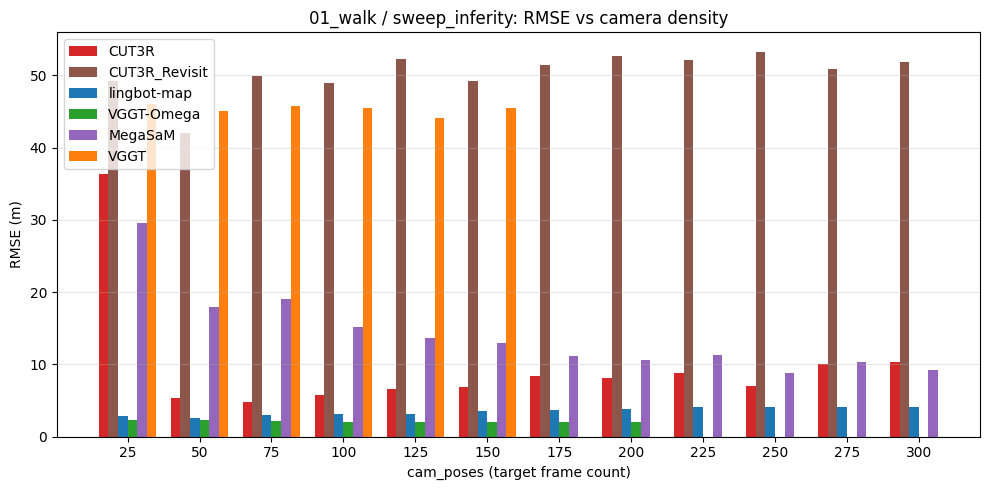

In [13]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir


results_path = case_dir() / "080_Experiments" /f"{experiment}"/ f"{experiment}_results.csv"

TECHNIQUE_ORDER = ["CUT3R","CUT3R_Revisit", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],  # no precedent for plain VGGT -- reuses the freed Reality_Scan slot
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],  # no precedent either -- n
}

df = pd.read_csv(results_path)
techniques = [t for t in TECHNIQUE_ORDER if t in df["technique"].unique()]
cam_poses_vals = sorted(df["cam_poses"].unique())

x = np.arange(len(cam_poses_vals))
width = 0.8 / max(len(techniques), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["rmse"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax.set_xticks(x)
ax.set_xticklabels(cam_poses_vals)
ax.set_xlabel("cam_poses (target frame count)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{case_name} / {experiment}: RMSE vs camera density")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

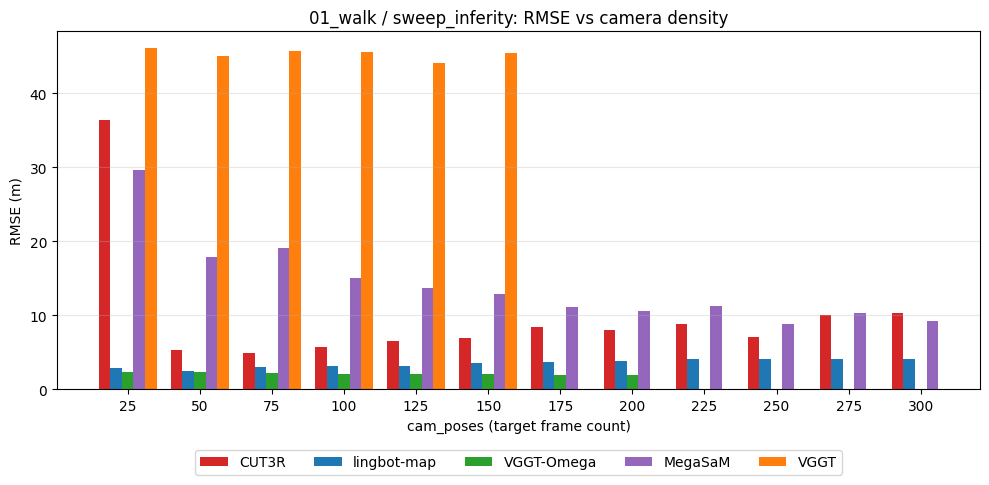

In [14]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir



set_case(case_name, experiment)
results_path = case_dir() / "080_Experiments" / f"{experiment}" / f"{experiment}_results.csv"

TECHNIQUE_ORDER = ["CUT3R", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],  # no precedent for plain VGGT -- reuses the freed Reality_Scan slot
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    
}

df = pd.read_csv(results_path)
techniques = [t for t in TECHNIQUE_ORDER if t in df["technique"].unique()]
cam_poses_vals = sorted(df["cam_poses"].unique())

x = np.arange(len(cam_poses_vals))
width = 0.8 / max(len(techniques), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["rmse"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax.set_xticks(x)
ax.set_xticklabels(cam_poses_vals)
ax.set_xlabel("cam_poses (target frame count)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{case_name} / {experiment}: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / f"{case_name}_{experiment}_RMSE_nocut3rr.svg", format="svg", bbox_inches="tight")

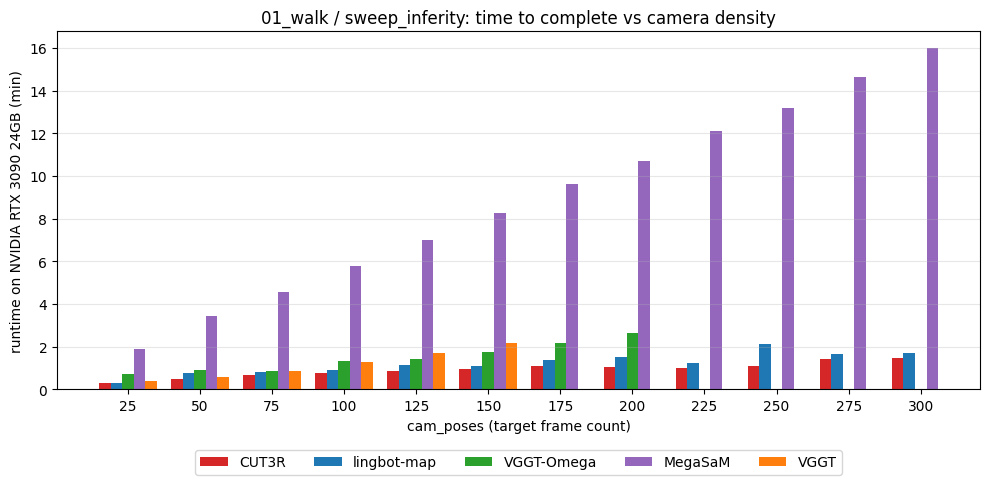

In [15]:
fig3, ax3 = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["runtime (min)"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax3.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax3.set_xticks(x)
ax3.set_xticklabels(cam_poses_vals)
ax3.set_xlabel("cam_poses (target frame count)")
ax3.set_ylabel("runtime on NVIDIA RTX 3090 24GB (min)")
ax3.set_title(f"{case_name} / {experiment}: time to complete vs camera density")
ax3.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))
ax3.grid(axis="y", alpha=0.3)
fig3.tight_layout()
fig3.savefig(out_dir / f"{case_name}_{experiment}_runtime.svg", format="svg", bbox_inches="tight")